In [1]:
import numpy as np
import fhrr_driver_torch as fd
import torch
from matplotlib import pyplot as plt
import tqdm
import random

Mnist prep

In [2]:
data_sources = {
    "training_images": "train-images-idx3-ubyte.gz",  # 60,000 training images.
    "test_images": "t10k-images-idx3-ubyte.gz",  # 10,000 test images.
    "training_labels": "train-labels-idx1-ubyte.gz",  # 60,000 training labels.
    "test_labels": "t10k-labels-idx1-ubyte.gz",  # 10,000 test labels.
}

In [3]:
import requests
import os

data_dir = "../_data"
os.makedirs(data_dir, exist_ok=True)

base_url = "https://ossci-datasets.s3.amazonaws.com/mnist/"

for fname in data_sources.values():
    fpath = os.path.join(data_dir, fname)
    if not os.path.exists(fpath):
        print("Downloading file: " + fname)
        resp = requests.get(base_url + fname, stream=True)
        resp.raise_for_status()  # Ensure download was succesful
        with open(fpath, "wb") as fh:
            for chunk in resp.iter_content(chunk_size=128):
                fh.write(chunk)

In [4]:
import gzip
import numpy as np

mnist_dataset = {}

# Images
for key in ("training_images", "test_images"):
    with gzip.open(os.path.join(data_dir, data_sources[key]), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(
            mnist_file.read(), np.uint8, offset=16
        ).reshape(-1, 28 * 28)
# Labels
for key in ("training_labels", "test_labels"):
    with gzip.open(os.path.join(data_dir, data_sources[key]), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=8)

In [5]:
x_train, y_train, x_test, y_test = (
    mnist_dataset["training_images"],
    mnist_dataset["training_labels"],
    mnist_dataset["test_images"],
    mnist_dataset["test_labels"],
)

In [6]:
print(
    "The shape of training images: {} and training labels: {}".format(
        x_train.shape, y_train.shape
    )
)
print(
    "The shape of test images: {} and test labels: {}".format(
        x_test.shape, y_test.shape
    )
)

The shape of training images: (60000, 784) and training labels: (60000,)
The shape of test images: (10000, 784) and test labels: (10000,)


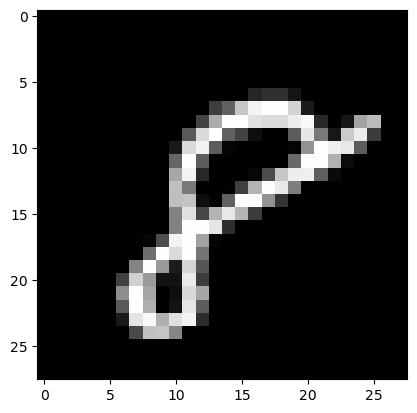

In [7]:
import matplotlib.pyplot as plt

# Take the 60,000th image (indexed at 59,999) from the training set,
# reshape from (784, ) to (28, 28) to have a valid shape for displaying purposes.
mnist_image = x_train[59999, :].reshape(28, 28)
# Set the color mapping to grayscale to have a black background.
plt.imshow(mnist_image, cmap="gray")
# Display the image.
plt.show()

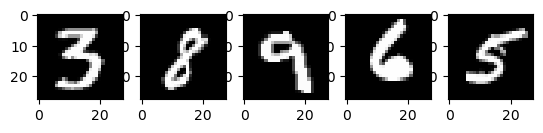

In [8]:
# Display 5 random images from the training set.
num_examples = 5
seed = 147197952744
rng = np.random.default_rng(seed)

fig, axes = plt.subplots(1, num_examples)
for sample, ax in zip(rng.choice(x_train, size=num_examples, replace=False), axes):
    ax.imshow(sample.reshape(28, 28), cmap="gray")

In [9]:
training_sample, test_sample = 10000, 1000
training_images = (x_train[0:training_sample] / 255).reshape(-1, 28, 28)[:,::2,::2].reshape(-1, 14*14)
test_images = x_test[0:test_sample] / 255

In [10]:
def one_hot_encoding(labels, dimension=10):
    # Define a one-hot variable for an all-zero vector
    # with 10 dimensions (number labels from 0 to 9).
    one_hot_labels = labels[..., None] == np.arange(dimension)[None]
    # Return one-hot encoded labels.
    return one_hot_labels.astype(np.float64)

In [11]:
training_labels = one_hot_encoding(y_train[:training_sample])
test_labels = one_hot_encoding(y_test[:test_sample])

FHRR stuff

In [ ]:
#encoding_map = torch.randn((10000, x_train.shape[1]))*torch.pi*0.01
encoding_map = fd.encoding_map(x_train.shape[1], 10000, "bind", torch.pi*0.01)
v_space = fd.fhrr_space(10000)
label_matrix = fd.init_random_mat((10000, 10))

In [ ]:
# def encode_image(img):
#     global encoding_map
#     encoding_angles = encoding_map@img
#     encoded_img = torch.exp(encoding_angles*1j)
#     return encoded_img
def encode_image(img):
    global encoding_map
    return encoding_map.forward(img)


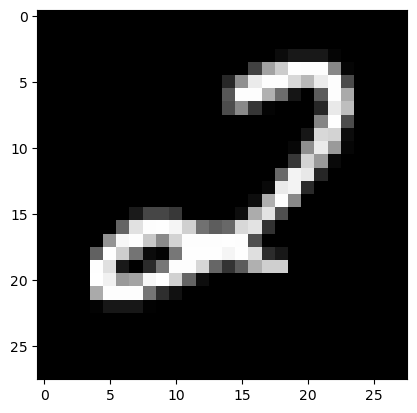

In [14]:
mnist_image = x_train[59991, :].reshape(28, 28)
# Set the color mapping to grayscale to have a black background.
plt.imshow(mnist_image, cmap="gray")
# Display the image.
plt.show()

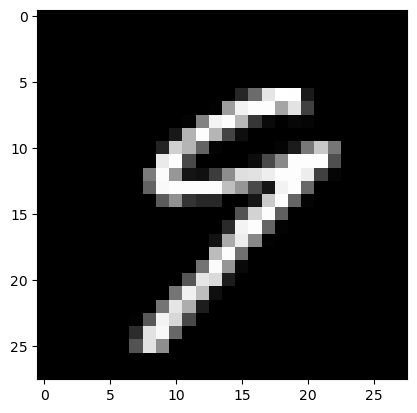

In [15]:
mnist_image = x_train[59990, :].reshape(28, 28)
# Set the color mapping to grayscale to have a black background.
plt.imshow(mnist_image, cmap="gray")
# Display the image.
plt.show()

In [16]:
img_vecs = torch.asarray(x_train[59989:59999, :], dtype=torch.double).T
print(img_vecs.shape)
encoded_vecs = encode_image(img_vecs)
print(encoded_vecs.shape)


torch.Size([784, 10])
torch.Size([10000, 10])


In [17]:
print(v_space.similarity_R(encoded_vecs[:,0:1], encoded_vecs[:,1:2]))

tensor([[0.0019]])


In [18]:
training_vecs = torch.asarray(x_train[:training_sample, :], dtype=torch.double).T
label_vecs = torch.asarray(training_labels, dtype=torch.complex128).T
training_embeddings = encode_image(training_vecs)
label_embeddings = label_matrix@label_vecs
hidden_embeddings = fd.init_random_mat((10000, training_sample))

In [19]:
learned_map = fd.block_learning_map(v_space, v_space, 100, (100, 100), decay_rate=0.00001)
learned_map_H1 = fd.block_learning_map(v_space, v_space, 100, (100, 100), decay_rate=0.00001)
learned_map_H2 = fd.block_learning_map(v_space, v_space, 100, (100, 100), decay_rate=0.00001)

In [20]:
learned_map.learn(training_embeddings, label_embeddings)
learned_map_H1.learn(training_embeddings, hidden_embeddings)
learned_map_H2.learn(hidden_embeddings, label_embeddings)

In [21]:
n=2
sample = training_embeddings[:, n:n+1]
output = learned_map.forwards(sample)
probs = v_space.get_pdf(output, label_matrix)
print(probs)
output2 = learned_map_H2.forwards(learned_map_H1.forwards(sample))
probs2 = v_space.get_pdf(output2, label_matrix)
print(probs2)

tensor([[0.0360, 0.0447, 0.1711, 0.0038, 0.4360, 0.0225, 0.0586, 0.0930, 0.0349,
         0.0994]])
tensor([[0.0158, 0.0156, 0.0551, 0.0403, 0.1220, 0.0162, 0.1666, 0.0773, 0.1969,
         0.2942]])


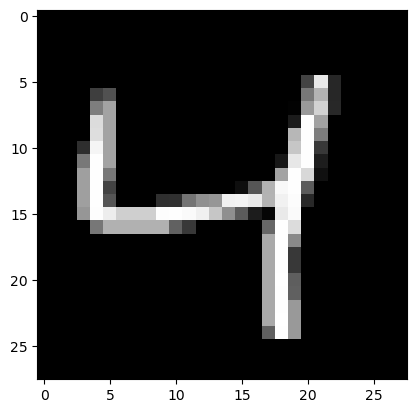

In [22]:
mnist_image = x_train[n, :].reshape(28, 28)
# Set the color mapping to grayscale to have a black background.
plt.imshow(mnist_image, cmap="gray")
# Display the image.
plt.show()

In [23]:
testing_vecs = torch.asarray(x_test, dtype=torch.double).T
testing_embeddings = encode_image(testing_vecs)

In [24]:
n=3
sample = testing_embeddings[:, n:n+1]
output = learned_map.forwards(sample)
probs = v_space.get_pdf(output, label_matrix)
print(probs)
output2 = learned_map_H2.forwards(learned_map_H1.forwards(sample))
probs2 = v_space.get_pdf(output2, label_matrix)
print(probs2)

tensor([[0.1237, 0.0141, 0.1146, 0.0272, 0.1075, 0.0178, 0.1547, 0.2736, 0.0170,
         0.1499]])
tensor([[0.0174, 0.1486, 0.1946, 0.2035, 0.0658, 0.0193, 0.1128, 0.1080, 0.0376,
         0.0924]])


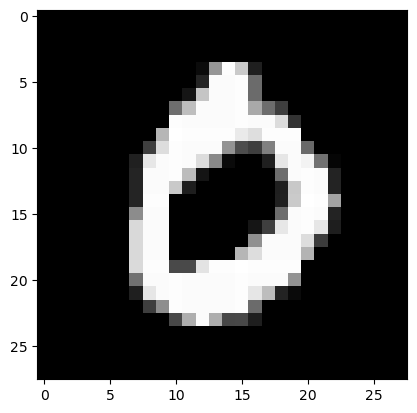

In [25]:
mnist_image = x_test[n, :].reshape(28, 28)
# Set the color mapping to grayscale to have a black background.
plt.imshow(mnist_image, cmap="gray")
# Display the image.
plt.show()

In [26]:
print(torch.argmax(v_space.get_pdf(learned_map.forwards(testing_embeddings), label_matrix), dim=1)[:20])
print(torch.asarray(y_test[:training_sample])[:20])

tensor([9, 0, 4, 7, 1, 1, 9, 4, 5, 6, 4, 8, 8, 4, 0, 6, 8, 0, 3, 6])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4],
       dtype=torch.uint8)


/tmp/ipykernel_16217/2511846239.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  print(torch.asarray(y_test[:training_sample])[:20])


In [27]:
train_accuracy_1 = torch.mean(torch.asarray(torch.argmax(v_space.get_pdf(learned_map.forwards(training_embeddings), label_matrix), dim=1) == torch.asarray(y_train[:training_sample]), dtype=torch.float64))
print(train_accuracy_1)
train_accuracy_2 = torch.mean(torch.asarray(torch.argmax(v_space.get_pdf(learned_map_H2.forwards(learned_map_H1.forwards(training_embeddings)), label_matrix), dim=1) == torch.asarray(y_train[:training_sample]), dtype=torch.float64))
print(train_accuracy_2)

tensor(0.9807)
tensor(0.1163)


In [28]:
test_accuracy_1 = torch.mean(torch.asarray(torch.argmax(v_space.get_pdf(learned_map.forwards(testing_embeddings), label_matrix), dim=1) == torch.asarray(y_test), dtype=torch.float64))
print(test_accuracy_1)
test_accuracy_2 = torch.mean(torch.asarray(torch.argmax(v_space.get_pdf(learned_map_H2.forwards(learned_map_H1.forwards(testing_embeddings)), label_matrix), dim=1) == torch.asarray(y_test), dtype=torch.float64))
print(test_accuracy_2)

tensor(0.1007)
tensor(0.1032)
